<a href="https://colab.research.google.com/github/MR-Xcloud/Exploratory-Data-analysis--Retail/blob/main/final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install face-alignment

Lip area coordinates: Top-left (x, y): (218, 167), Width: 185, Height: 35


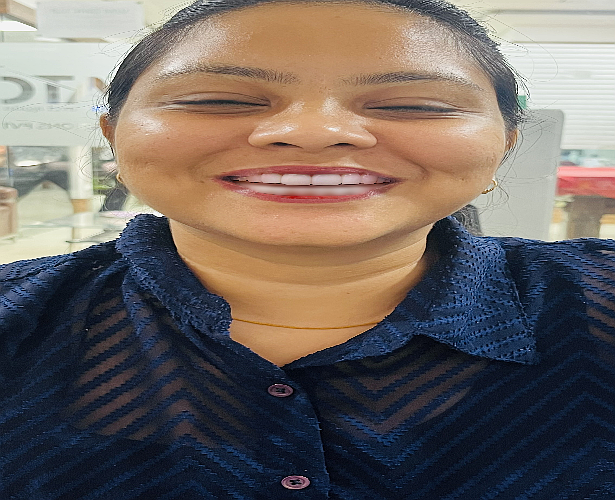

Enhanced final image saved to /content/enhanced_final_image.jpg


In [89]:
import face_alignment
from matplotlib import pyplot as plt
import cv2
import numpy as np
from PIL import Image, ImageEnhance, ImageFilter
from google.colab.patches import cv2_imshow

# Function to automatically resize the input image
def resize_image(image, output_width, output_height):
    return cv2.resize(image, (output_width, output_height))

# Initialize face alignment model
fa = face_alignment.FaceAlignment(face_alignment.LandmarksType.TWO_D, flip_input=False, device='cpu')

# Load the input image
img = cv2.imread("/content/ImportedPhoto.746536753.778706.jpeg")
if img is None:
    print("Error: Could not load image. Check the file path.")
else:
    output_width, output_height = 615, 500
    img = resize_image(img, output_width, output_height)

    # Convert the resized image to RGB
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Detect landmarks
    landmarks = fa.get_landmarks(rgb_img)

    # Load the replacement image
    replacement_img = cv2.imread("/content/cosmetic-dental-care-500x500-removebg-preview (2).png")
    if replacement_img is None:
        print("Error: Could not load replacement image.")
    else:
        # Loop over detected landmarks
        for landmark_set in landmarks:
            # Extract the coordinates for the lip area (approximate teeth region)
            lip_points = np.array([[int(landmark_set[i][0]), int(landmark_set[i][1])] for i in range(48, 68)], dtype=np.int32)

            # Find the bounding box for the lip area
            (x, y, w, h) = cv2.boundingRect(lip_points)
            print(f"Lip area coordinates: Top-left (x, y): ({x}, {y}), Width: {w}, Height: {h}")

            padding = 3  # Adjust this value as needed
            x = max(x - padding, 0)
            y = max(y - padding, 0)
            w = min(w + 2 * padding, img.shape[1] - x)
            h = min(h + 2 * padding, img.shape[0] - y)

            # Resize replacement image to fit the bounding box dimensions
            replacement_img_resized = cv2.resize(replacement_img, (w, h))

            # Create a mask for the replacement image
            mask = np.zeros((h, w), dtype=np.uint8)
            cv2.fillConvexPoly(mask, lip_points - [x, y], 255)

            # Create a region of interest (ROI) in the original image
            roi = img[y:y+h, x:x+w]

            # Blend the replacement image onto the original image using seamless cloning
            img[y:y+h, x:x+w] = cv2.seamlessClone(replacement_img_resized, roi, mask, (w//2, h//2), cv2.NORMAL_CLONE)

            # Optional: Draw the landmarks and bounding box for visualization
            # cv2.polylines(img, [lip_points], isClosed=True, color=(0, 255, 0), thickness=1)

        # Convert the image from BGR to RGB for PIL compatibility
        final_img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        final_img_pil = Image.fromarray(final_img_rgb)

        # Step 1: Increase Sharpness
        sharpness_enhancer = ImageEnhance.Sharpness(final_img_pil)
        final_img_pil = sharpness_enhancer.enhance(2)  # Adjust the sharpness factor as needed

        # Step 2: Blurry edges at the lips
        # Convert the resized replacement image to PIL for blurring
        replacement_img_pil = Image.fromarray(cv2.cvtColor(replacement_img_resized, cv2.COLOR_BGR2RGB))
        blurred_replacement_img_pil = replacement_img_pil.filter(ImageFilter.GaussianBlur(radius=50))

        # Convert back to OpenCV format for further processing
        blurred_replacement_img = cv2.cvtColor(np.array(blurred_replacement_img_pil), cv2.COLOR_RGB2BGR)

        # Step 3: Adjust Contrast
        contrast_enhancer = ImageEnhance.Contrast(final_img_pil)
        final_img_pil = contrast_enhancer.enhance(1)  # Adjust the contrast factor as needed

        # Step 4: Adjust Brightness
        brightness_enhancer = ImageEnhance.Brightness(final_img_pil)
        final_img_pil = brightness_enhancer.enhance(1)  # Adjust the brightness factor as needed

        # Convert back to OpenCV format for final processing
        final_img = cv2.cvtColor(np.array(final_img_pil), cv2.COLOR_RGB2BGR)

        # Display the enhanced image
        cv2_imshow(final_img)
        cv2.waitKey(0)
        cv2.destroyAllWindows()

        # Save the enhanced final image
        enhanced_output_path = "/content/enhanced_final_image.jpg"
        cv2.imwrite(enhanced_output_path, final_img)
        print(f"Enhanced final image saved to {enhanced_output_path}")


Lip area coordinates: Top-left (x, y): (199, 200), Width: 100, Height: 47


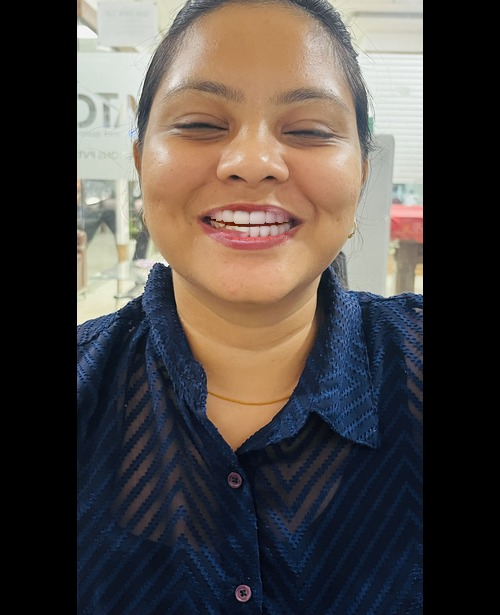

Final image saved to /content/final_image.jpg


In [92]:
import face_alignment
from matplotlib import pyplot as plt
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Initialize face alignment model
fa = face_alignment.FaceAlignment(face_alignment.LandmarksType.TWO_D, flip_input=False, device='cpu')

# Load the input image
img = cv2.imread("/content/ImportedPhoto.746536753.778706 (1).jpeg")
if img is None:
    print("Error: Could not load image. Check the file path.")
else:
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Detect landmarks
    landmarks = fa.get_landmarks(rgb_img)

    # Load the replacement image
    replacement_img = cv2.imread("/content/teeth1 (4).png")
    if replacement_img is None:
        print("Error: Could not load replacement image.")
    else:
        # Loop over detected landmarks
        for landmark_set in landmarks:
            # Extract the coordinates for the lip area (approximate teeth region)
            lip_points = np.array([[int(landmark_set[i][0]), int(landmark_set[i][1])] for i in range(48,68)], dtype=np.int32)

            # Find the bounding box for the lip area
            (x, y, w, h) = cv2.boundingRect(lip_points)
            print(f"Lip area coordinates: Top-left (x, y): ({x}, {y}), Width: {w}, Height: {h}")

            padding = 1 # Adjust this value as needed
            x = max(x - padding, 0)
            y = max(y - padding, 0)
            w = min(w + 2 * padding, img.shape[1] - x)
            h = min(h + 2 * padding, img.shape[0] - y)


            # Resize replacement image to fit the bounding box dimensions
            replacement_img_resized = cv2.resize(replacement_img, (w, h))

            # Create a mask for the replacement image
            mask = np.zeros((h, w), dtype=np.uint8)
            cv2.fillConvexPoly(mask, lip_points - [x, y], 255)

            # Create a region of interest (ROI) in the original image
            roi = img[y:y+h, x:x+w]

            # Blend the replacement image onto the original image using seamless cloning
            img[y:y+h, x:x+w] = cv2.seamlessClone(replacement_img_resized, roi, mask, (w//2, h//2), cv2.NORMAL_CLONE)

            # Optional: Draw the landmarks and bounding box for visualization
            # cv2.polylines(img, [lip_points], isClosed=True, color=(0, 255, 0), thickness=1)

        # Display the result with landmarks and bounding box
        cv2_imshow(img)
        cv2.waitKey(0)
        cv2.destroyAllWindows()

        output_path = "/content/final_image.jpg"
        cv2.imwrite(output_path, img)
        print(f"Final image saved to {output_path}")


Lip area coordinates: Top-left (x, y): (157, 233), Width: 155, Height: 35


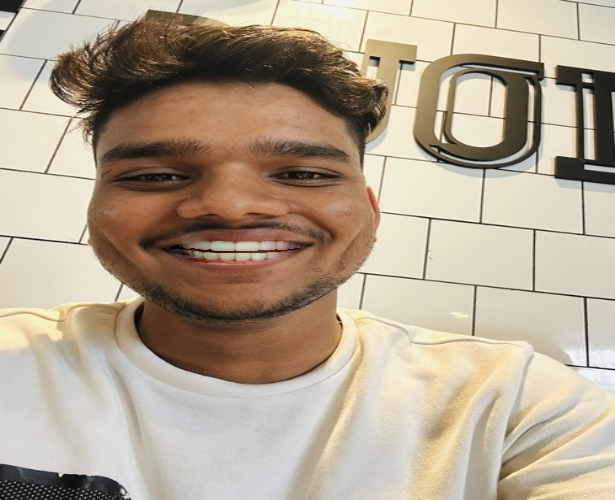

Final image saved to /content/final_image.jpg


In [56]:
import face_alignment
from matplotlib import pyplot as plt
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Function to automatically resize the input image
def resize_image(image, output_width, output_height):
    return cv2.resize(image, (output_width, output_height))

# Initialize face alignment model
fa = face_alignment.FaceAlignment(face_alignment.LandmarksType.TWO_D, flip_input=False, device='cpu')

# Load the input image
img = cv2.imread("/content/Skype_Picture_2024_08_24T10_52_52_983Z (1).jpeg")
if img is None:
    print("Error: Could not load image. Check the file path.")
else:
    output_width, output_height = 615,500
    img = resize_image(img, output_width, output_height)

    # Convert the resized image to RGB
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Detect landmarks
    landmarks = fa.get_landmarks(rgb_img)

    # Load the replacement image
    replacement_img = cv2.imread("/content/teeth1 (4).png")
    if replacement_img is None:
        print("Error: Could not load replacement image.")
    else:
        # Loop over detected landmarks
        for landmark_set in landmarks:
            # Extract the coordinates for the lip area (approximate teeth region)
            lip_points = np.array([[int(landmark_set[i][0]), int(landmark_set[i][1])] for i in range(48, 68)], dtype=np.int32)

            # Find the bounding box for the lip area
            (x, y, w, h) = cv2.boundingRect(lip_points)
            print(f"Lip area coordinates: Top-left (x, y): ({x}, {y}), Width: {w}, Height: {h}")

            padding = 1  # Adjust this value as needed
            x = max(x - padding, 0)
            y = max(y - padding, 0)
            w = min(w + 2 * padding, img.shape[1] - x)
            h = min(h + 2 * padding, img.shape[0] - y)

            # Resize replacement image to fit the bounding box dimensions
            replacement_img_resized = cv2.resize(replacement_img, (w, h))

            # Create a mask for the replacement image
            mask = np.zeros((h, w), dtype=np.uint8)
            cv2.fillConvexPoly(mask, lip_points - [x, y], 255)

            # Create a region of interest (ROI) in the original image
            roi = img[y:y+h, x:x+w]

            # Blend the replacement image onto the original image using seamless cloning
            img[y:y+h, x:x+w] = cv2.seamlessClone(replacement_img_resized, roi, mask, (w//2, h//2), cv2.NORMAL_CLONE)

            # Optional: Draw the landmarks and bounding box for visualization
            # cv2.polylines(img, [lip_points], isClosed=True, color=(0, 255, 0), thickness=1)

        # Display the result with landmarks and bounding box
        cv2_imshow(img)
        cv2.waitKey(0)
        cv2.destroyAllWindows()

        output_path = "/content/final_image.jpg"
        cv2.imwrite(output_path, img)
        print(f"Final image saved to {output_path}")

Lip area coordinates: Top-left (x, y): (263, 224), Width: 83, Height: 39


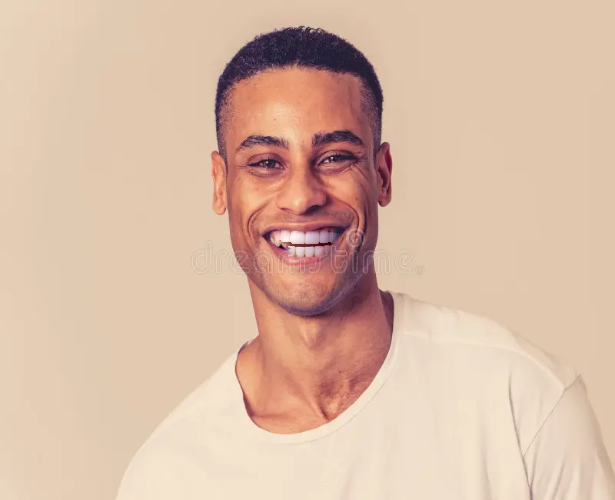

Final image saved to /content/final_image.jpg


In [60]:
import face_alignment
from matplotlib import pyplot as plt
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Function to automatically resize the input image
def resize_image(image, output_width, output_height):
    return cv2.resize(image, (output_width, output_height))

# Initialize face alignment model
fa = face_alignment.FaceAlignment(face_alignment.LandmarksType.TWO_D, flip_input=False, device='cpu')

# Load the input image
img = cv2.imread("/content/new im.jpg")
if img is None:
    print("Error: Could not load image. Check the file path.")
else:
    output_width, output_height = 615,500
    img = resize_image(img, output_width, output_height)

    # Convert the resized image to RGB
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Detect landmarks
    landmarks = fa.get_landmarks(rgb_img)

    # Load the replacement image
    replacement_img = cv2.imread("/content/teeth1 (4).png")
    if replacement_img is None:
        print("Error: Could not load replacement image.")
    else:
        # Loop over detected landmarks
        for landmark_set in landmarks:
            # Extract the coordinates for the lip area (approximate teeth region)
            lip_points = np.array([[int(landmark_set[i][0]), int(landmark_set[i][1])] for i in range(48, 68)], dtype=np.int32)

            # Find the bounding box for the lip area
            (x, y, w, h) = cv2.boundingRect(lip_points)
            print(f"Lip area coordinates: Top-left (x, y): ({x}, {y}), Width: {w}, Height: {h}")

            padding = 5  # Adjust this value as needed
            x = max(x - padding, 0)
            y = max(y - padding, 0)
            w = min(w + 2 * padding, img.shape[1] - x)
            h = min(h + 2 * padding, img.shape[0] - y)

            # Resize replacement image to fit the bounding box dimensions
            replacement_img_resized = cv2.resize(replacement_img, (w, h))

            # Create a mask for the replacement image
            mask = np.zeros((h, w), dtype=np.uint8)
            cv2.fillConvexPoly(mask, lip_points - [x, y], 255)

            # Create a region of interest (ROI) in the original image
            roi = img[y:y+h, x:x+w]

            # Blend the replacement image onto the original image using seamless cloning
            img[y:y+h, x:x+w] = cv2.seamlessClone(replacement_img_resized, roi, mask, (w//2, h//2), cv2.NORMAL_CLONE)

            # Optional: Draw the landmarks and bounding box for visualization
            # cv2.polylines(img, [lip_points], isClosed=True, color=(0, 255, 0), thickness=1)

        # Display the result with landmarks and bounding box
        cv2_imshow(img)
        cv2.waitKey(0)
        cv2.destroyAllWindows()

        output_path = "/content/final_image.jpg"
        cv2.imwrite(output_path, img)
        print(f"Final image saved to {output_path}")

Lip area coordinates: Top-left (x, y): (237, 261), Width: 94, Height: 44


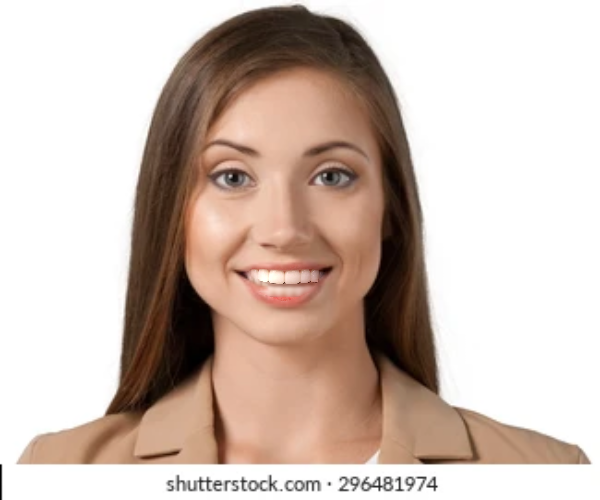

Final image saved to /content/final_image.jpg


In [76]:
import face_alignment
from matplotlib import pyplot as plt
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Function to automatically resize the input image
def resize_image(image, output_width, output_height):
    return cv2.resize(image, (output_width, output_height))

# Initialize face alignment model
fa = face_alignment.FaceAlignment(face_alignment.LandmarksType.TWO_D, flip_input=False, device='cpu')

# Load the input image
img = cv2.imread("/content/human-face-women-portrait-260nw-296481974.jpg")
if img is None:
    print("Error: Could not load image. Check the file path.")
else:
    output_width, output_height = 600,500
    img = resize_image(img, output_width, output_height)

    # Convert the resized image to RGB
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Detect landmarks
    landmarks = fa.get_landmarks(rgb_img)

    # Load the replacement image
    replacement_img = cv2.imread("/content/cosmetic-dental-care-500x500-removebg-preview (2).png")
    if replacement_img is None:
        print("Error: Could not load replacement image.")
    else:
        # Loop over detected landmarks
        for landmark_set in landmarks:
            # Extract the coordinates for the lip area (approximate teeth region)
            lip_points = np.array([[int(landmark_set[i][0]), int(landmark_set[i][1])] for i in range(48, 68)], dtype=np.int32)

            # Find the bounding box for the lip area
            (x, y, w, h) = cv2.boundingRect(lip_points)
            print(f"Lip area coordinates: Top-left (x, y): ({x}, {y}), Width: {w}, Height: {h}")

            padding = 3  # Adjust this value as needed
            x = max(x - padding, 0)
            y = max(y - padding, 0)
            w = min(w + 2 * padding, img.shape[1] - x)
            h = min(h + 2 * padding, img.shape[0] - y)

            # Resize replacement image to fit the bounding box dimensions
            replacement_img_resized = cv2.resize(replacement_img, (w, h))

            # Create a mask for the replacement image
            mask = np.zeros((h, w), dtype=np.uint8)
            cv2.fillConvexPoly(mask, lip_points - [x, y], 255)

            # Create a region of interest (ROI) in the original image
            roi = img[y:y+h, x:x+w]

            # Blend the replacement image onto the original image using seamless cloning
            img[y:y+h, x:x+w] = cv2.seamlessClone(replacement_img_resized, roi, mask, (w//2, h//2), cv2.NORMAL_CLONE)

            # Optional: Draw the landmarks and bounding box for visualization
            # cv2.polylines(img, [lip_points], isClosed=True, color=(0, 255, 0), thickness=1)

        # Display the result with landmarks and bounding box
        cv2_imshow(img)
        cv2.waitKey(0)
        cv2.destroyAllWindows()

        output_path = "/content/final_image.jpg"
        cv2.imwrite(output_path, img)
        print(f"Final image saved to {output_path}")

Lip area coordinates: Top-left (x, y): (237, 261), Width: 94, Height: 44


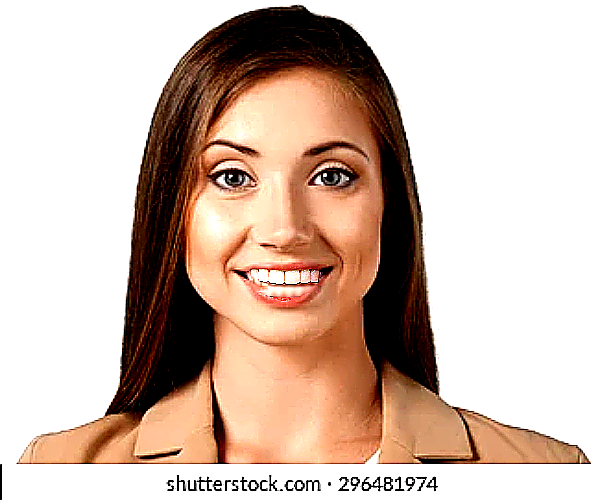

Enhanced final image saved to /content/enhanced_final_image.jpg


In [86]:
import face_alignment
from matplotlib import pyplot as plt
import cv2
import numpy as np
from PIL import Image, ImageEnhance, ImageFilter
from google.colab.patches import cv2_imshow

# Function to automatically resize the input image
def resize_image(image, output_width, output_height):
    return cv2.resize(image, (output_width, output_height))

# Initialize face alignment model
fa = face_alignment.FaceAlignment(face_alignment.LandmarksType.TWO_D, flip_input=False, device='cpu')

# Load the input image
img = cv2.imread("/content/human-face-women-portrait-260nw-296481974.jpg")
if img is None:
    print("Error: Could not load image. Check the file path.")
else:
    output_width, output_height = 600, 500
    img = resize_image(img, output_width, output_height)

    # Convert the resized image to RGB
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Detect landmarks
    landmarks = fa.get_landmarks(rgb_img)

    # Load the replacement image
    replacement_img = cv2.imread("/content/cosmetic-dental-care-500x500-removebg-preview (2).png")
    if replacement_img is None:
        print("Error: Could not load replacement image.")
    else:
        # Loop over detected landmarks
        for landmark_set in landmarks:
            # Extract the coordinates for the lip area (approximate teeth region)
            lip_points = np.array([[int(landmark_set[i][0]), int(landmark_set[i][1])] for i in range(48, 68)], dtype=np.int32)

            # Find the bounding box for the lip area
            (x, y, w, h) = cv2.boundingRect(lip_points)
            print(f"Lip area coordinates: Top-left (x, y): ({x}, {y}), Width: {w}, Height: {h}")

            padding = 3  # Adjust this value as needed
            x = max(x - padding, 0)
            y = max(y - padding, 0)
            w = min(w + 2 * padding, img.shape[1] - x)
            h = min(h + 2 * padding, img.shape[0] - y)

            # Resize replacement image to fit the bounding box dimensions
            replacement_img_resized = cv2.resize(replacement_img, (w, h))

            # Create a mask for the replacement image
            mask = np.zeros((h, w), dtype=np.uint8)
            cv2.fillConvexPoly(mask, lip_points - [x, y], 255)

            # Create a region of interest (ROI) in the original image
            roi = img[y:y+h, x:x+w]

            # Blend the replacement image onto the original image using seamless cloning
            img[y:y+h, x:x+w] = cv2.seamlessClone(replacement_img_resized, roi, mask, (w//2, h//2), cv2.NORMAL_CLONE)

            # Optional: Draw the landmarks and bounding box for visualization
            # cv2.polylines(img, [lip_points], isClosed=True, color=(0, 255, 0), thickness=1)

        # Convert the image from BGR to RGB for PIL compatibility
        final_img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        final_img_pil = Image.fromarray(final_img_rgb)

        # Step 1: Increase Sharpness
        sharpness_enhancer = ImageEnhance.Sharpness(final_img_pil)
        final_img_pil = sharpness_enhancer.enhance(10)  # Adjust the sharpness factor as needed

        # Step 2: Blurry edges at the lips
        # Convert the resized replacement image to PIL for blurring
        replacement_img_pil = Image.fromarray(cv2.cvtColor(replacement_img_resized, cv2.COLOR_BGR2RGB))
        blurred_replacement_img_pil = replacement_img_pil.filter(ImageFilter.GaussianBlur(radius=50))

        # Convert back to OpenCV format for further processing
        blurred_replacement_img = cv2.cvtColor(np.array(blurred_replacement_img_pil), cv2.COLOR_RGB2BGR)

        # Step 3: Adjust Contrast
        contrast_enhancer = ImageEnhance.Contrast(final_img_pil)
        final_img_pil = contrast_enhancer.enhance(1.4)  # Adjust the contrast factor as needed

        # Step 4: Adjust Brightness
        brightness_enhancer = ImageEnhance.Brightness(final_img_pil)
        final_img_pil = brightness_enhancer.enhance(1.2)  # Adjust the brightness factor as needed

        # Convert back to OpenCV format for final processing
        final_img = cv2.cvtColor(np.array(final_img_pil), cv2.COLOR_RGB2BGR)

        # Display the enhanced image
        cv2_imshow(final_img)
        cv2.waitKey(0)
        cv2.destroyAllWindows()

        # Save the enhanced final image
        enhanced_output_path = "/content/enhanced_final_image.jpg"
        cv2.imwrite(enhanced_output_path, final_img)
        print(f"Enhanced final image saved to {enhanced_output_path}")
